<a href="https://colab.research.google.com/github/gorodnichenko16-cell/-/blob/main/%D0%94%D0%97_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D1%8B_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
!pip -q install kagglehub torch torchvision pandas tqdm

import os
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("hijest/englishrussian-dictionary-for-machine-translate")
print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'englishrussian-dictionary-for-machine-translate' dataset.
Path to dataset files: /kaggle/input/englishrussian-dictionary-for-machine-translate
['rus.txt']


In [58]:
import os
import re
import random
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [59]:
data_path = "/kaggle/input/englishrussian-dictionary-for-machine-translate/rus.txt"

pairs = []
with open(data_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            eng = parts[0].strip()
            rus = parts[1].strip()
            pairs.append((eng, rus))

print("pairs:", len(pairs))
print("example:", pairs[0])

pairs: 363386
example: ('Go.', 'Марш!')


In [60]:
# очистка и токенизация
SOS, EOS, PAD = "<sos>", "<eos>", "<pad>"

def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-zA-Zа-яА-ЯёЁ0-9\s\.\,\!\?\-']", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def tokenize(text):
    return clean_text(text).split()

pairs = [(clean_text(e), clean_text(r)) for e, r in pairs]
pairs = [(e, r) for e, r in pairs if e and r]

src_tokens = [tokenize(e) for e, r in pairs]
tgt_tokens = [[SOS] + tokenize(r) + [EOS] for e, r in pairs]

In [61]:
# словари
def build_vocab(token_lists, min_freq=2):
    counter = Counter()
    for lst in token_lists:
        counter.update(lst)
    vocab = [PAD, SOS, EOS]
    vocab += [w for w, c in counter.items() if c >= min_freq and w not in vocab]
    stoi = {w: i for i, w in enumerate(vocab)}
    itos = {i: w for w, i in stoi.items()}
    return vocab, stoi, itos

src_vocab, src_stoi, src_itos = build_vocab(src_tokens, min_freq=2)
tgt_vocab, tgt_stoi, tgt_itos = build_vocab(tgt_tokens, min_freq=2)

src_pad_idx = src_stoi[PAD]
tgt_pad_idx = tgt_stoi[PAD]

print("src vocab:", len(src_vocab))
print("tgt vocab:", len(tgt_vocab))

src vocab: 20043
tgt vocab: 47281


In [62]:
# датасет и кодирование
max_src_len = 15
max_tgt_len = 15

def encode(tokens, stoi, max_len):
    ids = [stoi.get(tok, stoi[PAD]) for tok in tokens]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [stoi[PAD]] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)

encoded_pairs = [
    (
        encode(s, src_stoi, max_src_len),
        encode(t, tgt_stoi, max_tgt_len)
    )
    for s, t in zip(src_tokens, tgt_tokens)
]

class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        return self.pairs[idx]

dataset = TranslationDataset(encoded_pairs)

n_train = int(0.9 * len(dataset))
n_val = len(dataset) - n_train
train_ds, val_ds = torch.utils.data.random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(seed)
)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(len(train_ds), len(val_ds))

327047 36339


Модели: GRU, GRU +1 слой, LSTM
GRU encoder/decoder

In [63]:
class EncoderGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=src_pad_idx)
        self.gru = nn.GRU(emb_dim, hid_dim, num_layers=num_layers, batch_first=True)

    def forward(self, src):
        emb = self.embedding(src)
        _, hidden = self.gru(emb)
        return hidden

class DecoderGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=tgt_pad_idx)
        self.gru = nn.GRU(emb_dim, hid_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, input_tok, hidden):
        input_tok = input_tok.unsqueeze(1)
        emb = self.embedding(input_tok)
        out, hidden = self.gru(emb, hidden)
        pred = self.fc_out(out.squeeze(1))
        return pred, hidden

In [64]:
# LSTM encoder/decoder
class EncoderLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=src_pad_idx)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=num_layers, batch_first=True)

    def forward(self, src):
        emb = self.embedding(src)
        _, (hidden, cell) = self.lstm(emb)
        return hidden, cell

class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=tgt_pad_idx)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, input_tok, hidden, cell):
        input_tok = input_tok.unsqueeze(1)
        emb = self.embedding(input_tok)
        out, (hidden, cell) = self.lstm(emb, (hidden, cell))
        pred = self.fc_out(out.squeeze(1))
        return pred, hidden, cell

In [65]:
# Seq2Seq модели
class Seq2SeqGRU(nn.Module):
    def __init__(self, encoder, decoder, tgt_sos_idx, max_tgt_len):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_sos_idx = tgt_sos_idx
        self.max_tgt_len = max_tgt_len

    def forward(self, src, tgt=None, teacher_forcing_ratio=0.5):
        B = src.size(0)
        hidden = self.encoder(src)
        inputs = torch.full((B,), self.tgt_sos_idx, device=src.device, dtype=torch.long)
        outputs = []
        for t in range(self.max_tgt_len):
            out, hidden = self.decoder(inputs, hidden)
            outputs.append(out.unsqueeze(1))
            if tgt is not None and random.random() < teacher_forcing_ratio:
                inputs = tgt[:, t]
            else:
                inputs = out.argmax(1)
        return torch.cat(outputs, dim=1)

class Seq2SeqLSTM(nn.Module):
    def __init__(self, encoder, decoder, tgt_sos_idx, max_tgt_len):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_sos_idx = tgt_sos_idx
        self.max_tgt_len = max_tgt_len

    def forward(self, src, tgt=None, teacher_forcing_ratio=0.5):
        B = src.size(0)
        hidden, cell = self.encoder(src)
        inputs = torch.full((B,), self.tgt_sos_idx, device=src.device, dtype=torch.long)
        outputs = []
        for t in range(self.max_tgt_len):
            out, hidden, cell = self.decoder(inputs, hidden, cell)
            outputs.append(out.unsqueeze(1))
            if tgt is not None and random.random() < teacher_forcing_ratio:
                inputs = tgt[:, t]
            else:
                inputs = out.argmax(1)
        return torch.cat(outputs, dim=1)

In [66]:
# обучение батчами
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for src, tgt in tqdm(loader, leave=False):
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        out = model(src, tgt, teacher_forcing_ratio=0.5)
        loss = criterion(out.view(-1, out.size(-1)), tgt.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            out = model(src, tgt, teacher_forcing_ratio=0.0)
            loss = criterion(out.view(-1, out.size(-1)), tgt.view(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

Запуск 3 экспериментов
 GRU, 1 слой

In [67]:
EMB_DIM = 128
HID_DIM = 256

gru1 = Seq2SeqGRU(
    EncoderGRU(len(src_vocab), EMB_DIM, HID_DIM, num_layers=1),
    DecoderGRU(len(tgt_vocab), EMB_DIM, HID_DIM, num_layers=1),
    tgt_sos_idx=tgt_stoi[SOS],
    max_tgt_len=max_tgt_len
).to(device)

opt = optim.Adam(gru1.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=tgt_pad_idx)

hist_gru1 = []
for epoch in range(1, 6):
    tr = train_epoch(gru1, train_loader, opt, crit)
    va = evaluate(gru1, val_loader, crit)
    hist_gru1.append((tr, va))
    print(f"GRU-1 Epoch {epoch}: train={tr:.4f}, val={va:.4f}")

GRU-1 Epoch 1: train=3.7925, val=3.2538


GRU-1 Epoch 2: train=2.4623, val=2.7673


GRU-1 Epoch 3: train=1.9792, val=2.5777


GRU-1 Epoch 4: train=1.6991, val=2.4757


GRU-1 Epoch 5: train=1.5160, val=2.4300


GRU, 2 слоя

In [68]:
gru2 = Seq2SeqGRU(
    EncoderGRU(len(src_vocab), EMB_DIM, HID_DIM, num_layers=2),
    DecoderGRU(len(tgt_vocab), EMB_DIM, HID_DIM, num_layers=2),
    tgt_sos_idx=tgt_stoi[SOS],
    max_tgt_len=max_tgt_len
).to(device)

opt = optim.Adam(gru2.parameters(), lr=1e-3)

hist_gru2 = []
for epoch in range(1, 6):
    tr = train_epoch(gru2, train_loader, opt, crit)
    va = evaluate(gru2, val_loader, crit)
    hist_gru2.append((tr, va))
    print(f"GRU-2 Epoch {epoch}: train={tr:.4f}, val={va:.4f}")

GRU-2 Epoch 1: train=3.7307, val=3.1598


GRU-2 Epoch 2: train=2.3950, val=2.6676


GRU-2 Epoch 3: train=1.8985, val=2.4735


GRU-2 Epoch 4: train=1.6200, val=2.3809


GRU-2 Epoch 5: train=1.4403, val=2.3134


LSTM, 1 слой

In [69]:
lstm1 = Seq2SeqLSTM(
    EncoderLSTM(len(src_vocab), EMB_DIM, HID_DIM, num_layers=1),
    DecoderLSTM(len(tgt_vocab), EMB_DIM, HID_DIM, num_layers=1),
    tgt_sos_idx=tgt_stoi[SOS],
    max_tgt_len=max_tgt_len
).to(device)

opt = optim.Adam(lstm1.parameters(), lr=1e-3)

hist_lstm1 = []
for epoch in range(1, 6):
    tr = train_epoch(lstm1, train_loader, opt, crit)
    va = evaluate(lstm1, val_loader, crit)
    hist_lstm1.append((tr, va))
    print(f"LSTM-1 Epoch {epoch}: train={tr:.4f}, val={va:.4f}")

LSTM-1 Epoch 1: train=3.7680, val=3.1681


LSTM-1 Epoch 2: train=2.4004, val=2.6636


LSTM-1 Epoch 3: train=1.8570, val=2.4318


LSTM-1 Epoch 4: train=1.5502, val=2.3337


LSTM-1 Epoch 5: train=1.3554, val=2.2769


In [70]:
# сравнение
results = pd.DataFrame([
    {"model": "GRU-1", "train_loss": hist_gru1[-1][0], "val_loss": hist_gru1[-1][1]},
    {"model": "GRU-2", "train_loss": hist_gru2[-1][0], "val_loss": hist_gru2[-1][1]},
    {"model": "LSTM-1", "train_loss": hist_lstm1[-1][0], "val_loss": hist_lstm1[-1][1]},
])

display(results)
results.to_csv("seq2seq_results.csv", index=False)

,model,train_loss,val_loss
0,GRU-1,1.516033,2.430012
1,GRU-2,1.440330,2.313366
2,LSTM-1,1.355350,2.276856


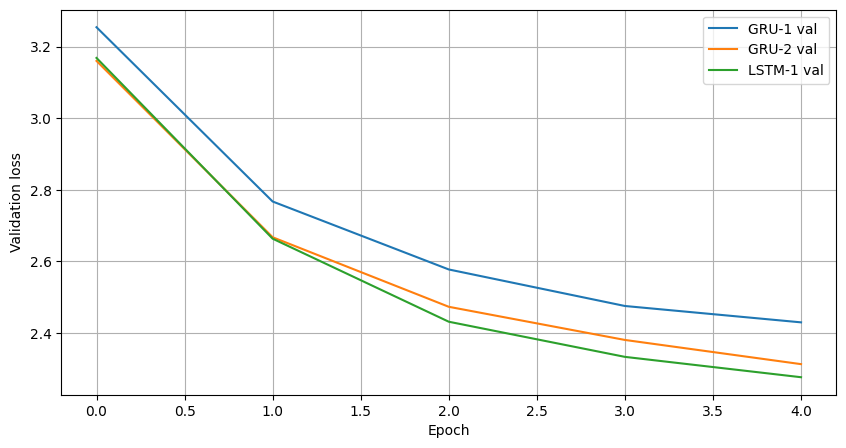

In [71]:
plt.figure(figsize=(10, 5))
plt.plot([x[1] for x in hist_gru1], label="GRU-1 val")
plt.plot([x[1] for x in hist_gru2], label="GRU-2 val")
plt.plot([x[1] for x in hist_lstm1], label="LSTM-1 val")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.legend()
plt.grid(True)
plt.show()